<a href="https://colab.research.google.com/github/iamrobby/Customer-Churn-reviewer/blob/main/Ecom_Customer_Churn_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix,classification_report

In [4]:
df=pd.read_excel('E Commerce Dataset.xlsx')

In [5]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [6]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [7]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [8]:
df.shape


(5630, 20)

In [9]:
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

In [10]:

def fill_missing_values(df, random_state=None):
    # Step 1: Identify numeric and categorical columns
    numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    categorical_columns = df.select_dtypes(include=['object']).columns.tolist()  # Include both string and category data

    # Step 2: Impute numeric columns
    numeric_imputer = SimpleImputer(strategy='mean')
    df[numeric_columns] = numeric_imputer.fit_transform(df[numeric_columns])

    # Step 3: Handle categorical columns
    for col in categorical_columns:
        if df[col].dtype == 'object':
            # Convert categorical column to one-hot encoded representation
            encoded_cols = pd.get_dummies(df[col], prefix=col)
            # Concatenate one-hot encoded columns
            df = pd.concat([df.drop(col, axis=1), encoded_cols], axis=1)

    # Step 4: Random Forest Iterative Imputer for the entire DataFrame
    rf_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=random_state))
    df = pd.DataFrame(rf_imputer.fit_transform(df), columns=df.columns)

    return df

# Call the function to fill missing values
df = fill_missing_values(df, random_state=42)

In [11]:
count_col = []
hist_col = []
for column in df.columns:
    unique_value = df[column].nunique()
    if unique_value <= 20:
        count_col.append(column)
    else:
        hist_col.append(column)

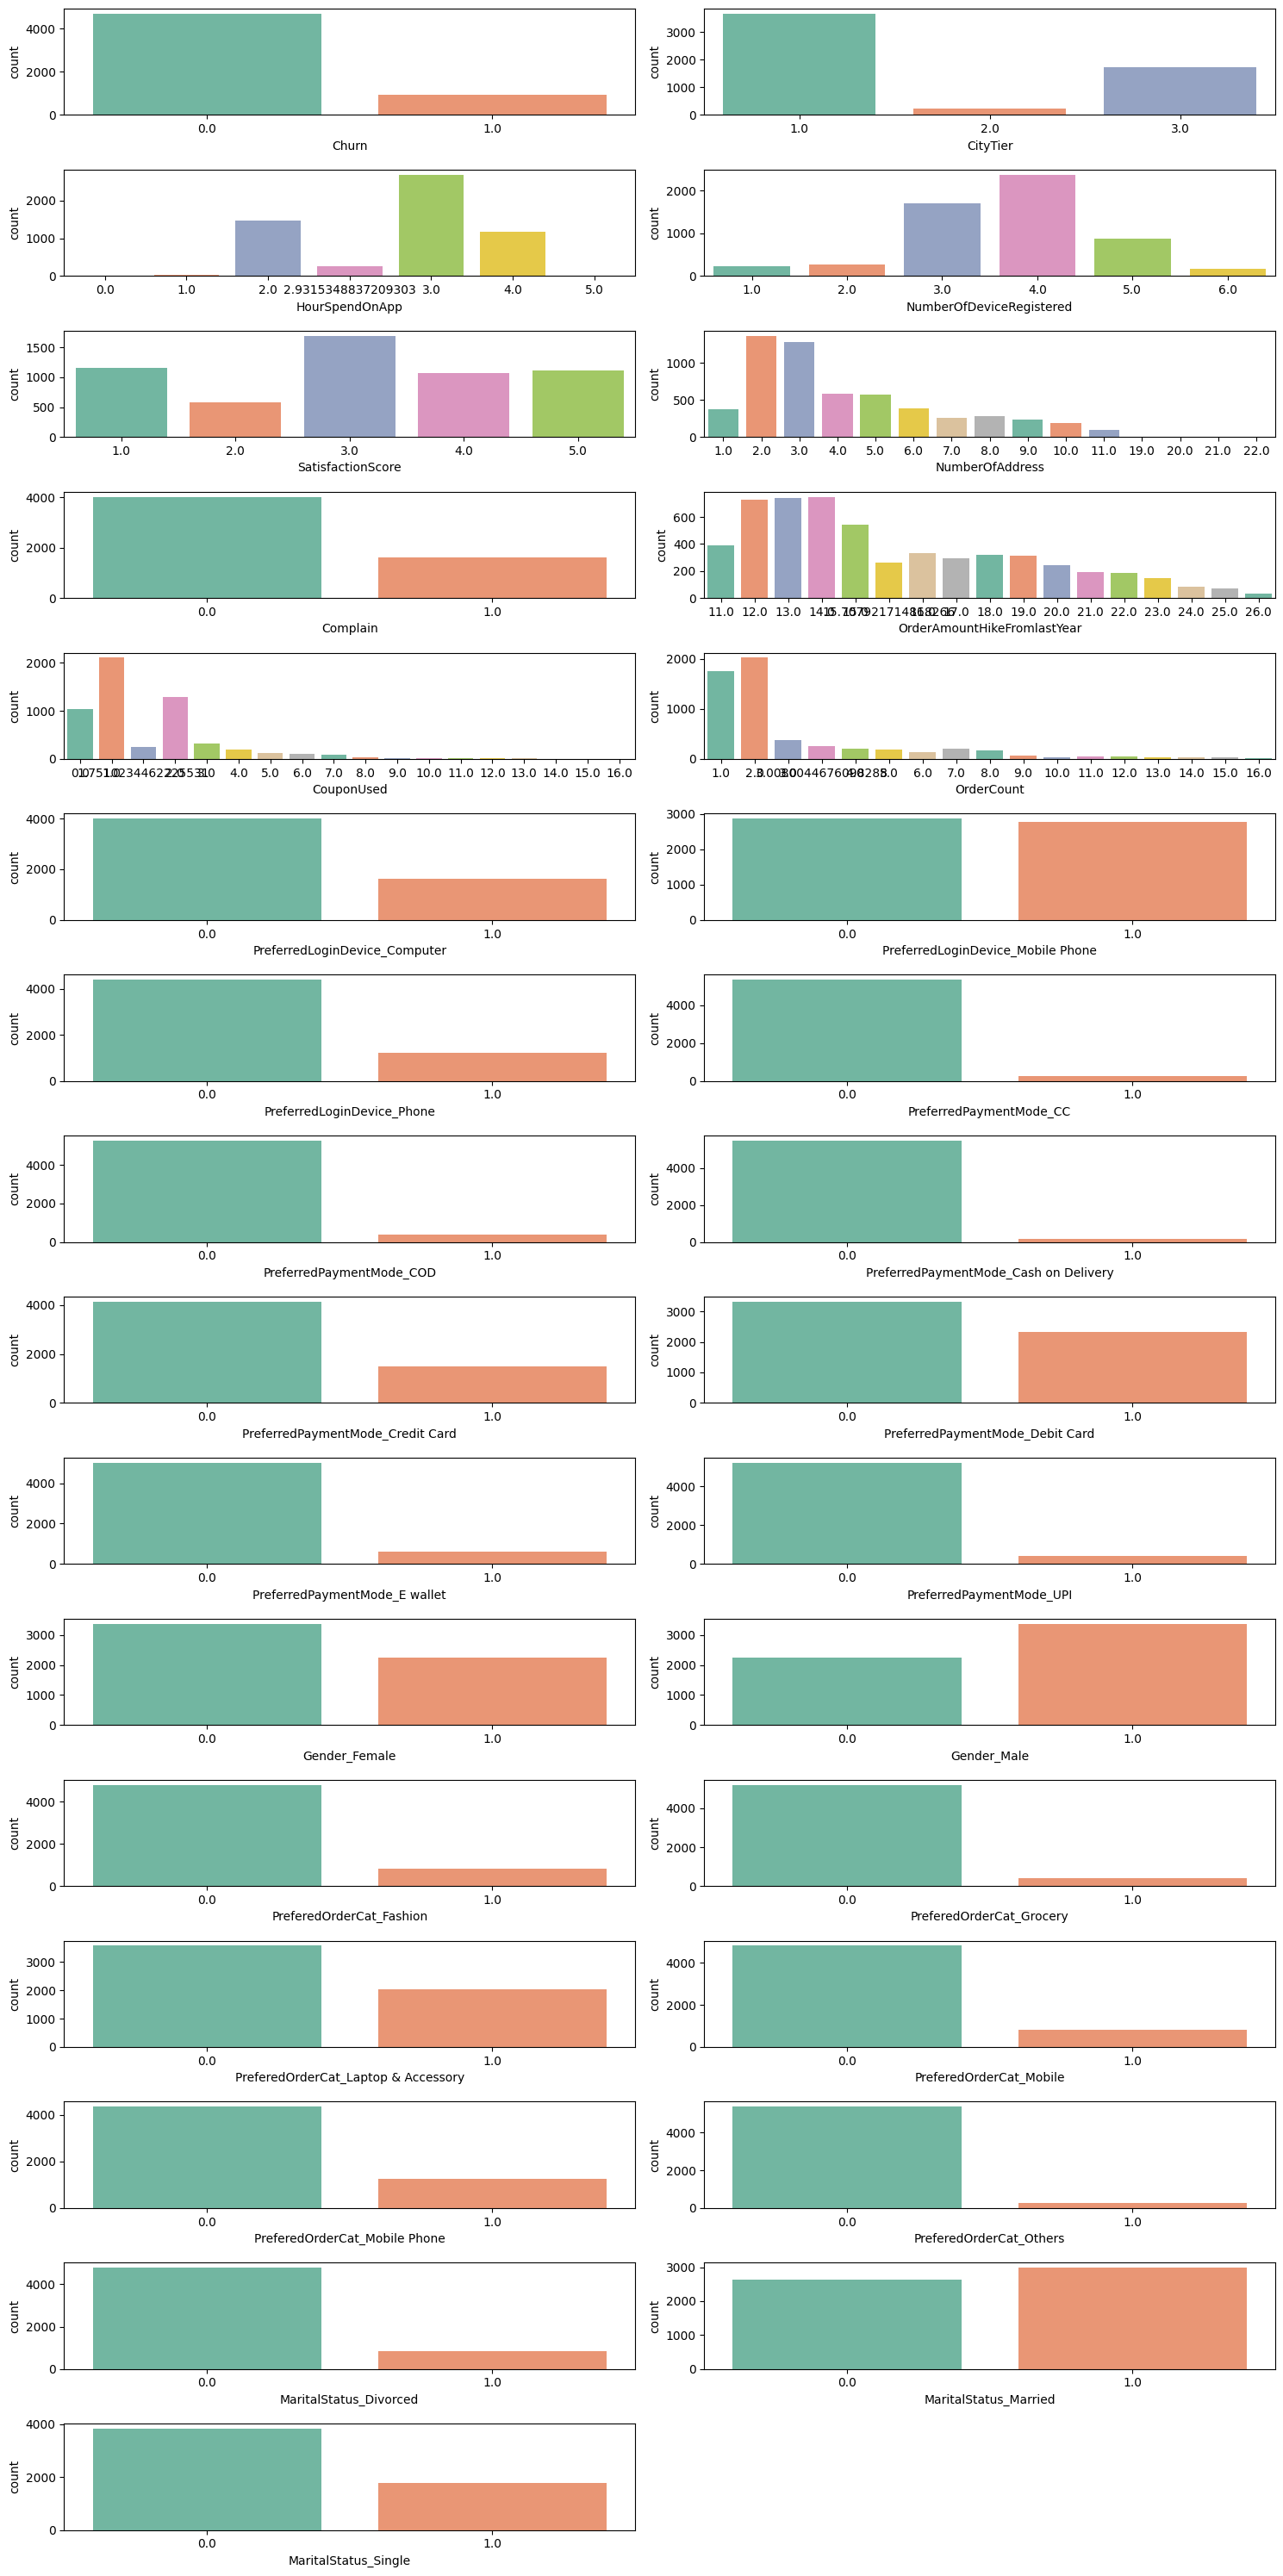

In [12]:
rows = len(count_col) // 2 + len(count_col) % 2
plt.figure(figsize=(15, 30))  # adjust size for readability
plot_num = 1
for col in count_col:
    plt.subplot(rows, 2, plot_num)
    sns.countplot(data=df, x=col, hue=col, palette="Set2", legend=False)
    plot_num += 1
plt.tight_layout()


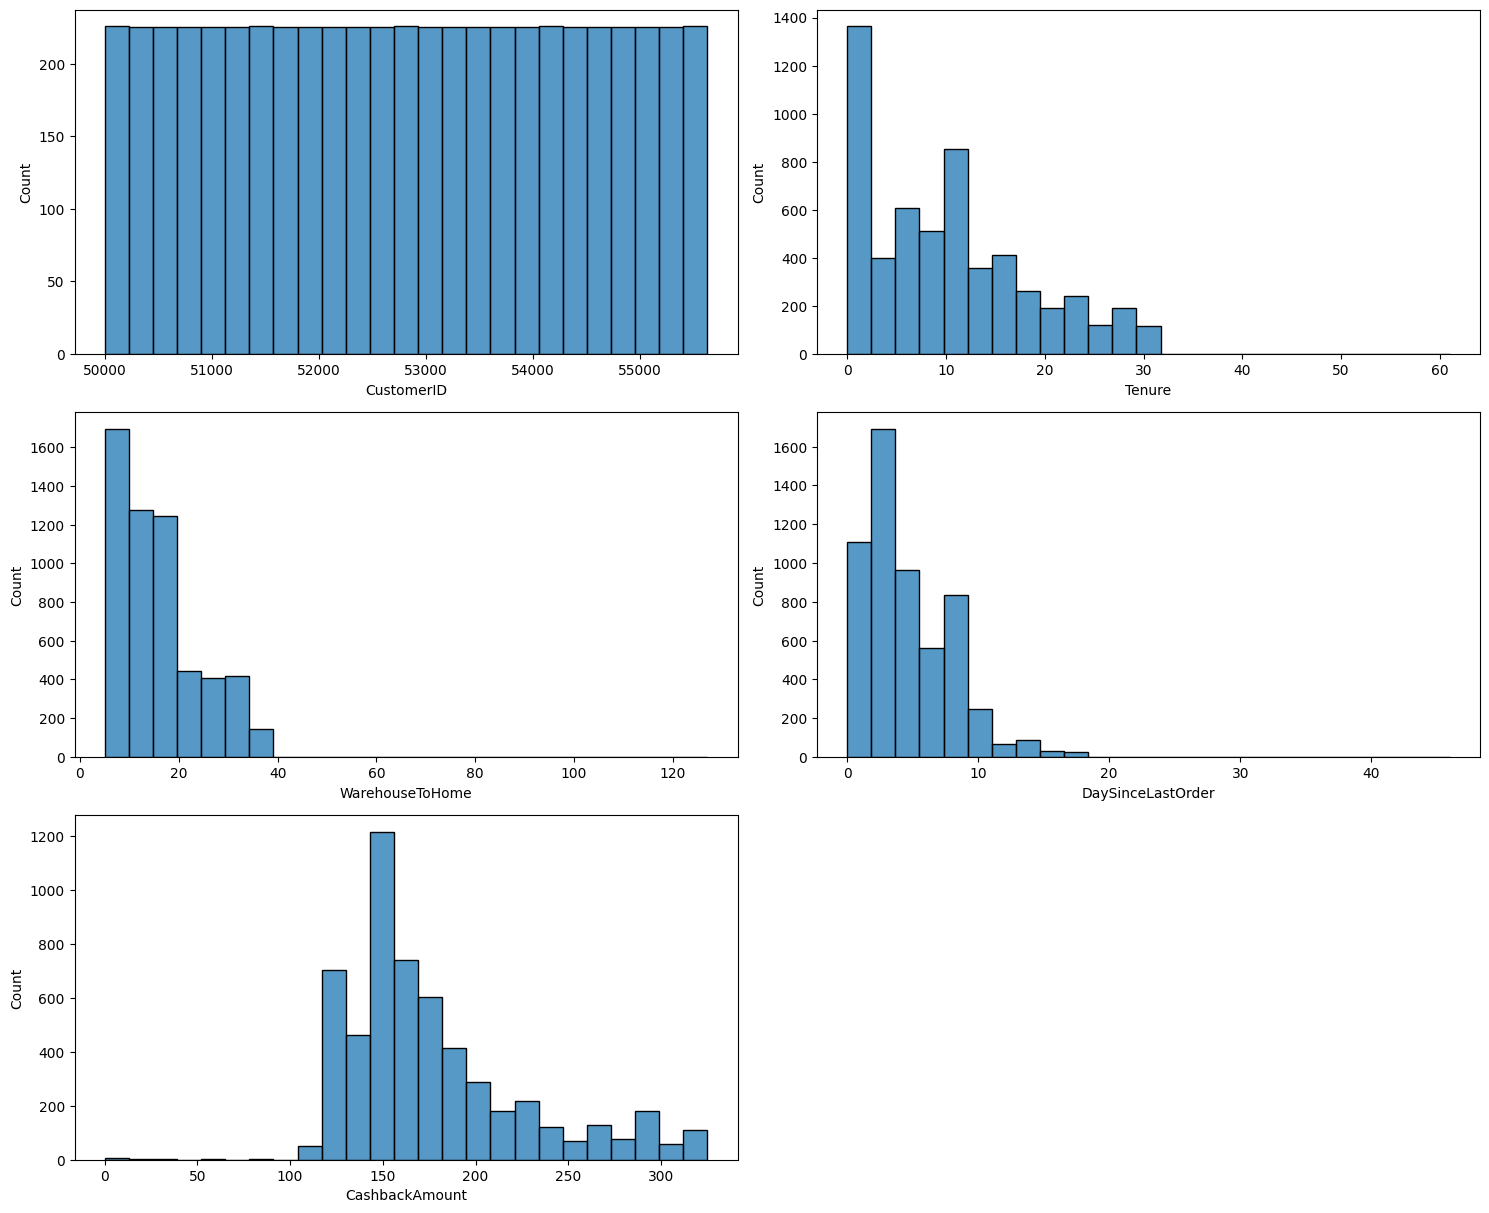

In [13]:
plt.figure(figsize=(15,40))
plot_num = 1
for col in hist_col:
    plt.subplot(10,2,plot_num)
    sns.histplot(data=df, x=col,bins=25)
    plot_num += 1
    plt.tight_layout()

ValueError: num must be an integer with 1 <= num <= 20, not 21

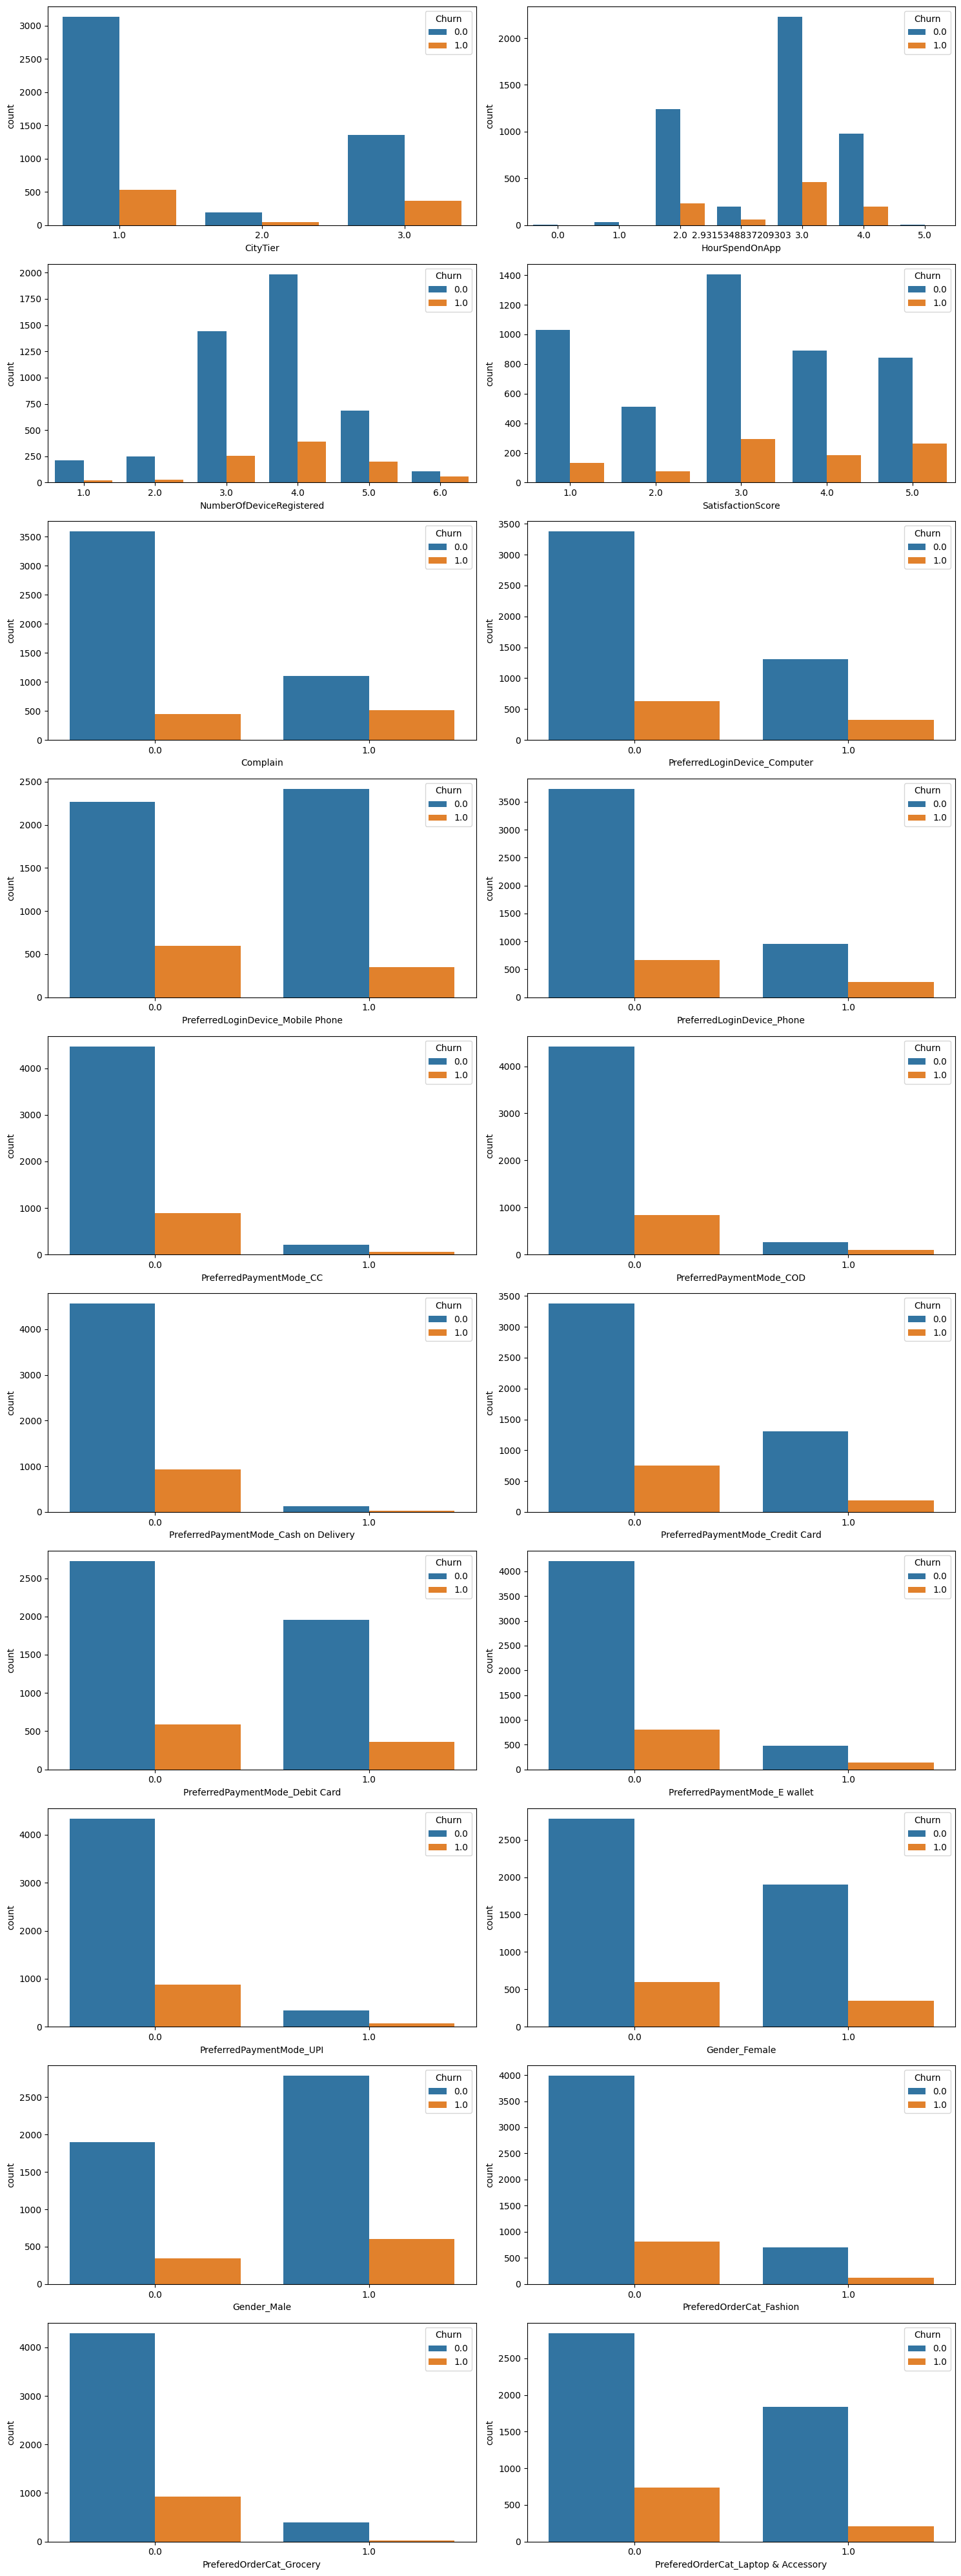

In [14]:
plt.figure(figsize=(15,40))
plot_num = 1
for col in count_col:
    if df[col].nunique() <= 8 and col != "Churn":
        plt.subplot(10,2,plot_num)
        sns.countplot(data=df, x=col, hue="Churn")
        plot_num += 1
        plt.tight_layout()

In [15]:
df.drop(columns=["CustomerID"],inplace=True)

In [16]:
x=df.drop(columns=["Churn"])
y=df["Churn"]

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

In [18]:
from imblearn.over_sampling import SMOTE

print('Before upsampling count of label 0 {}'.format(sum(y_train==0)))
print('Before upsampling count of label 1 {}'.format(sum(y_train==1)))
# Minority Over Sampling Technique
sm = SMOTE(sampling_strategy = 1, random_state=1)
x_train_s, y_train_s = sm.fit_resample(x_train, y_train.ravel())

print('After upsampling count of label 0 {}'.format(sum(y_train_s==0)))
print('After upsampling count of label 1 {}'.format(sum(y_train_s==1)))

Before upsampling count of label 0 3749
Before upsampling count of label 1 755
After upsampling count of label 0 3749
After upsampling count of label 1 3749


/tmp/ipykernel_2367/3725033751.py:7: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  x_train_s, y_train_s = sm.fit_resample(x_train, y_train.ravel())


In [19]:
# Libraries
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics

from sklearn.linear_model import LogisticRegressionCV, RidgeClassifierCV, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier


In [20]:
#Initialize the models
models=[
    #Ensemble
    AdaBoostClassifier(),
    BaggingClassifier(),
    GradientBoostingClassifier(),
    RandomForestClassifier(),

    #Linear Models
    LogisticRegressionCV(),
    RidgeClassifierCV(),

    #Nearest Neighbour
    KNeighborsClassifier(),

    #XGBoost
    XGBClassifier()
]

metrics_cols = ['model_name','test_accuracy','test_precision','test_recall','test_f1']

model_name=[]
test_acuracy=[]
test_precision=[]
test_recall=[]
test_f1=[]


In [21]:
print(y_train.shape, y_test.shape)


(4504,) (1126,)


In [22]:
scoring = ['accuracy','precision', 'recall', 'f1']

for model in models:
    cv_results = model_selection.cross_validate(model, x, y, cv=5,
                                                scoring=scoring, return_train_score=True)
    model_name.append(model.__class__.__name__)
    test_acuracy.append(round(cv_results['test_accuracy'].mean(),3)*100)
    test_precision.append(round(cv_results['test_precision'].mean(),3)*100)
    test_recall.append(round(cv_results['test_recall'].mean(),3)*100)
    test_f1.append(round(cv_results['test_f1'].mean(),3)*100)

metrics_data = [model_name, test_acuracy, test_precision, test_recall, test_f1]
m = {n:m for n,m in zip(metrics_cols,metrics_data)}
model_metrics = pd.DataFrame(m)
model_metrics = model_metrics.sort_values('test_accuracy', ascending=False)
metrics_styled = model_metrics.style.background_gradient(subset=['test_accuracy', 'test_f1'], cmap='summer')
metrics_styled


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,model_name,test_accuracy,test_precision,test_recall,test_f1
7,XGBClassifier,99.200000,98.300000,96.900000,97.600000
3,RandomForestClassifier,98.500000,98.800000,92.400000,95.500000
1,BaggingClassifier,97.900000,97.300000,89.800000,93.400000
2,GradientBoostingClassifier,91.900000,85.200000,62.800000,72.200000
4,LogisticRegressionCV,89.400000,77.700000,52.500000,62.600000
0,AdaBoostClassifier,89.000000,72.900000,55.000000,62.500000
6,KNeighborsClassifier,87.500000,70.400000,44.800000,54.800000
5,RidgeClassifierCV,87.400000,86.500000,29.700000,44.300000


Here The best model is XGBoostClassifier so we will take that

In [23]:
finalmodel=XGBClassifier()
finalmodel.fit(x_train,y_train)
testresult=finalmodel.predict(x_test)
trainresult=finalmodel.predict(x_train)
finalmodel.score(x_test,y_test)

0.9795737122557726

Feature Importance Gain


<Axes: >

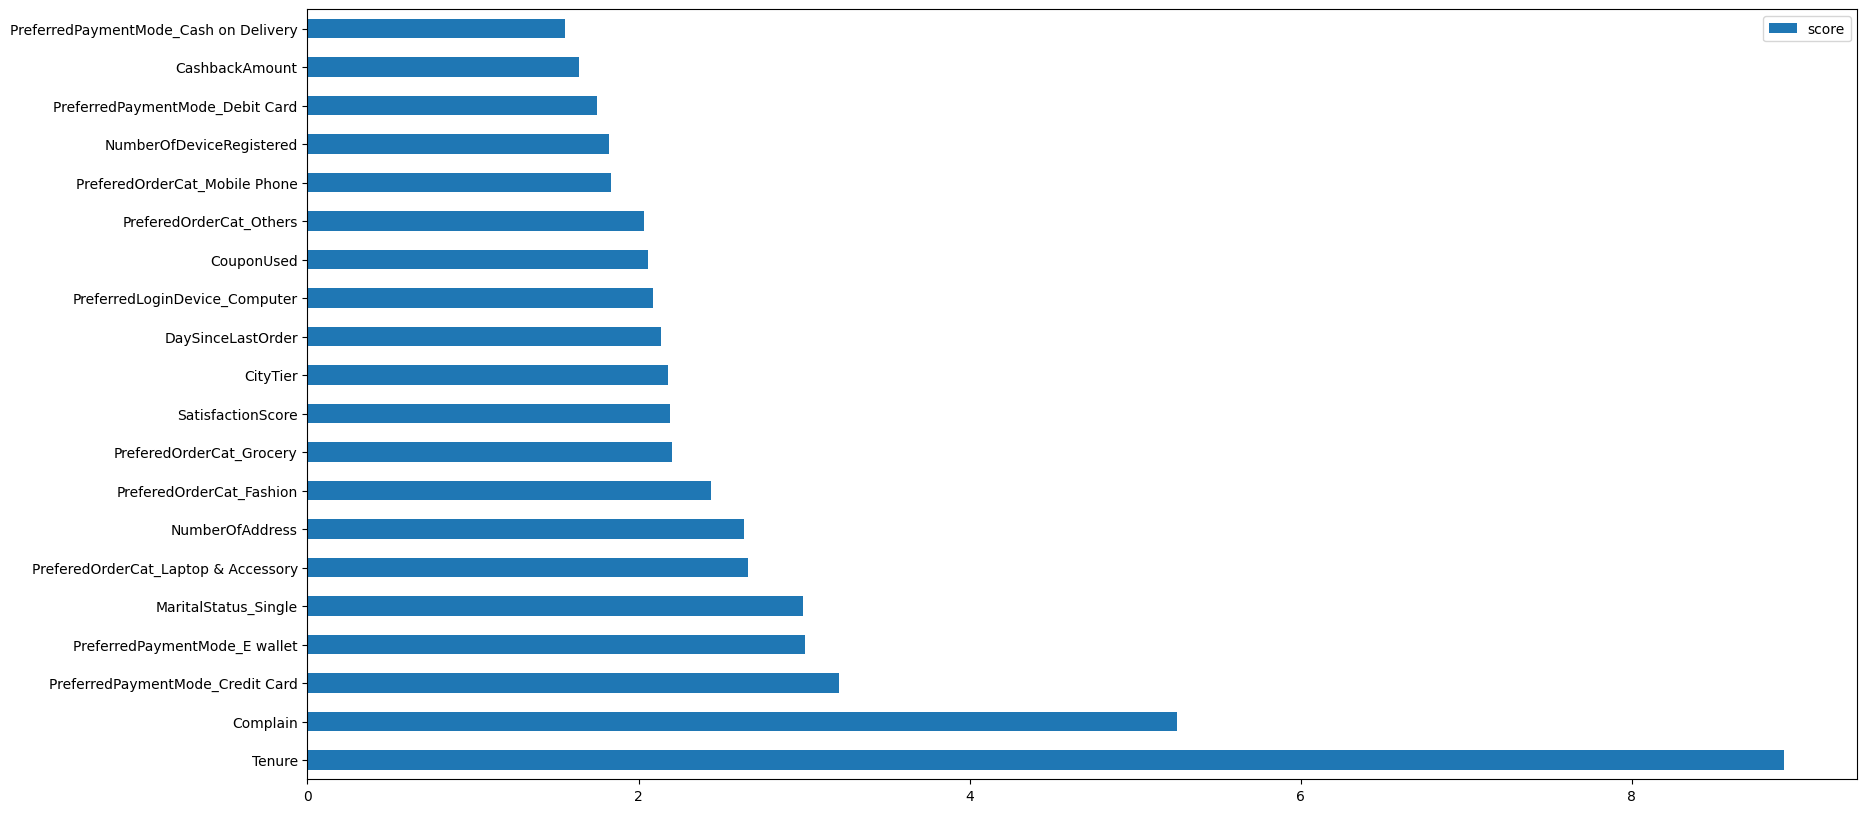

In [25]:
print("Feature Importance Gain")
feature_important = finalmodel.get_booster().get_score(importance_type="gain")
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh', figsize = (20,10))

Feature Importance Weight


<Axes: >

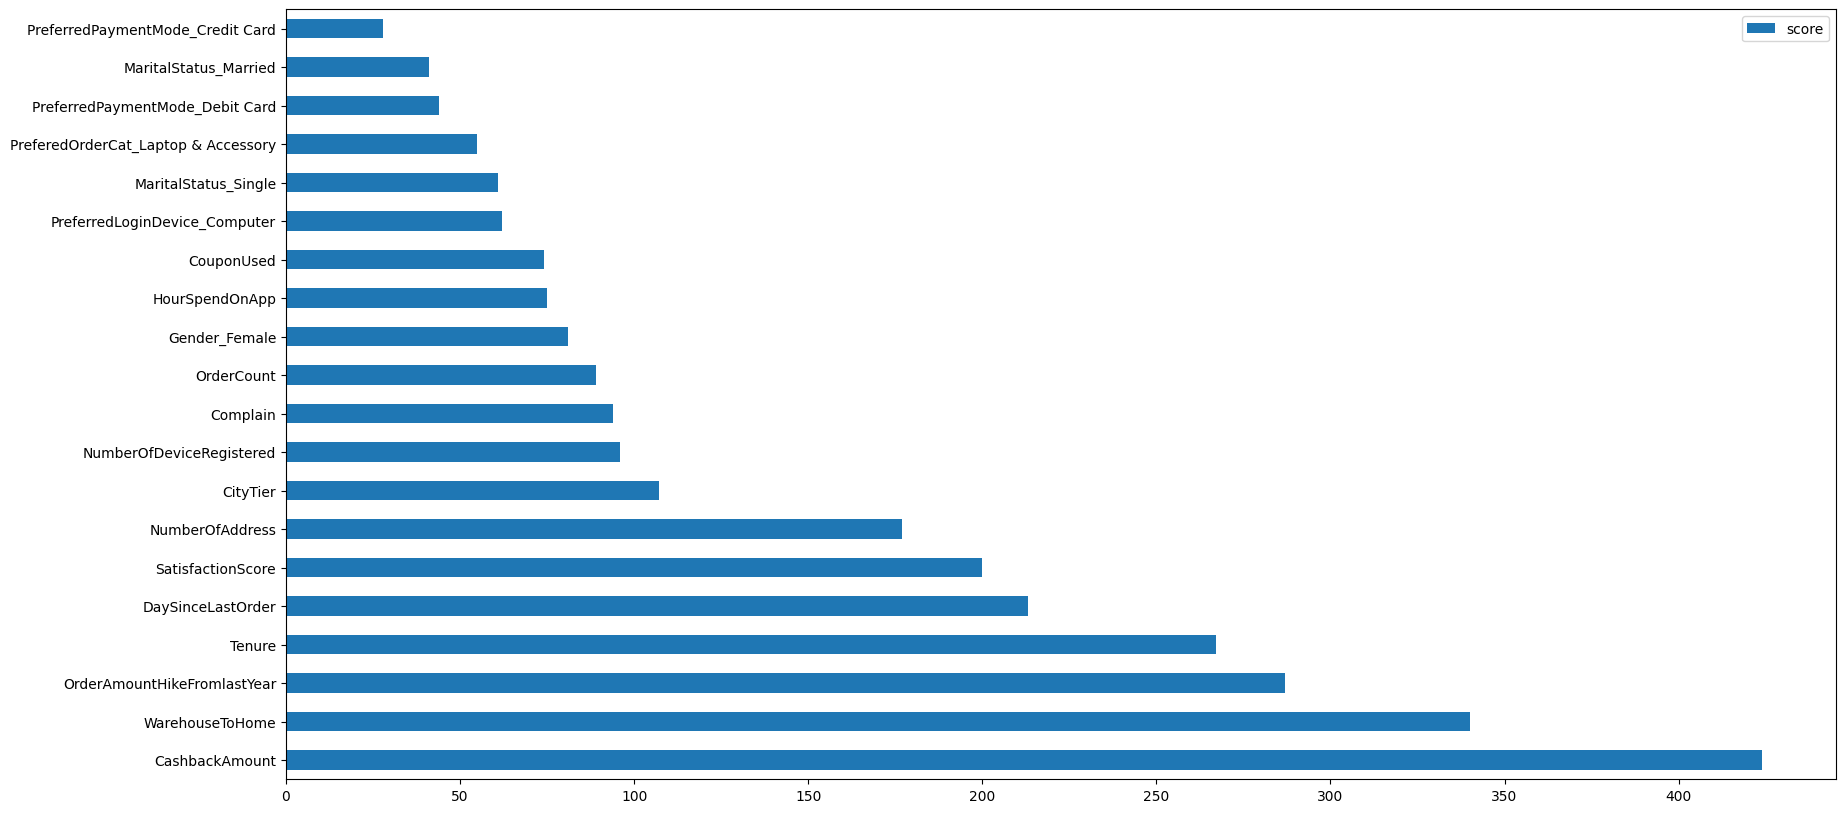

In [26]:
print("Feature Importance Weight")
feature_important = finalmodel.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh', figsize = (20,10))

In [27]:
cols_to_drop = [
    'PreferredLoginDevice_Computer', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone',
    'PreferredPaymentMode_CC', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Cash on Delivery', 'PreferredPaymentMode_Credit Card',
    'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI',
    'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory',
    'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others'
]
x = x.drop(cols_to_drop, axis=1, errors='ignore')

In [28]:
x_train.drop(cols_to_drop, axis = 1, inplace = True)
x_test.drop(cols_to_drop, axis = 1, inplace = True)

In [29]:
x.head()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Gender_Female,Gender_Male,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,4.000000,3.0,6.0,3.000000,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.0,159.93,1.0,0.0,0.0,0.0,1.0
1,10.189899,1.0,8.0,3.000000,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.0,120.90,0.0,1.0,0.0,0.0,1.0
2,10.189899,1.0,30.0,2.000000,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.0,120.28,0.0,1.0,0.0,0.0,1.0
3,0.000000,3.0,15.0,2.000000,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.0,134.07,0.0,1.0,0.0,0.0,1.0
4,0.000000,1.0,12.0,2.931535,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.0,129.60,0.0,1.0,0.0,0.0,1.0


In [30]:
x_test = x_test.values
x_train = x_train.values

In [31]:
finalmodel=XGBClassifier()
finalmodel.fit(x_train,y_train)
testresult=finalmodel.predict(x_test)
trainresult=finalmodel.predict(x_train)
finalmodel.score(x_test,y_test)

0.9724689165186501

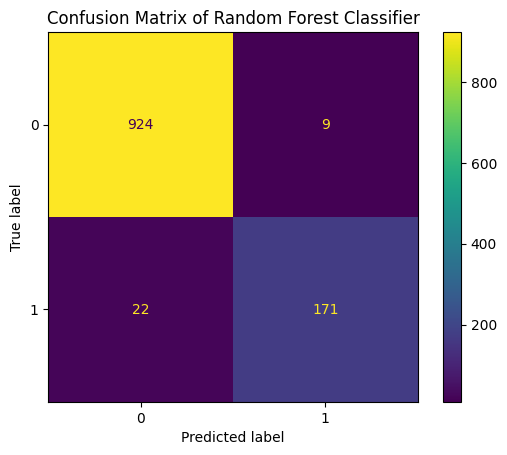

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, testresult, labels=finalmodel.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=finalmodel.classes_)
disp.plot()
plt.title('Confusion Matrix of Random Forest Classifier')
plt.show()

In [33]:
# Make predictions on the test set
y_pred = finalmodel.predict(x_test)

# Create a list to store the actual and predicted values
results = []

# Store the actual and predicted log_price values in the list
for actual, predicted in zip(y_test, y_pred):
    results.append((actual, predicted))

# Convert the list into a DataFrame
XGBoost_df = pd.DataFrame(results, columns=['Actual', 'Predicted'])

# Print the DataFrame
XGBoost_df.tail(10)

,Actual,Predicted
1116,0.0,0
1117,0.0,0
1118,0.0,0
1119,0.0,0
1120,0.0,0
1121,1.0,1
1122,0.0,0
1123,1.0,1
1124,0.0,0
1125,0.0,0


In [34]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 93.2 MB/s eta 0:00:00


In [35]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 3s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴

In [36]:
import urllib
print("Password/Endpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

Password/Endpoint IP for localtunnel is: 34.58.232.3


In [37]:
import joblib

In [38]:
joblib.dump(finalmodel, 'xgboost_model.joblib')
print("Model saved as 'xgboost_model.joblib'")

Model saved as 'xgboost_model.joblib'


In [39]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd
import numpy as np

# Load the trained XGBoost model
finalmodel = joblib.load('xgboost_model.joblib')

st.title('Customer Churn Prediction App')
st.write('Enter the customer details below to predict churn.')

# Define the ordered list of features expected by the model
# This order is derived from the 'x' DataFrame after preprocessing
feature_columns = [
    'Tenure',
    'CityTier',
    'WarehouseToHome',
    'HourSpendOnApp',
    'NumberOfDeviceRegistered',
    'SatisfactionScore',
    'NumberOfAddress',
    'Complain',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder',
    'CashbackAmount',
    'Gender_Female',
    'Gender_Male',
    'MaritalStatus_Divorced',
    'MaritalStatus_Married',
    'MaritalStatus_Single'
]

# Create input widgets for numerical features
input_data = {}

# Numerical inputs with reasonable ranges and defaults
input_data['Tenure'] = st.number_input('Tenure (months)', min_value=0.0, max_value=100.0, value=10.0, step=1.0)
input_data['CityTier'] = st.number_input('City Tier', min_value=1.0, max_value=3.0, value=1.0, step=1.0)
input_data['WarehouseToHome'] = st.number_input('Warehouse To Home (miles)', min_value=5.0, max_value=150.0, value=15.0, step=1.0)
input_data['HourSpendOnApp'] = st.number_input('Hours Spend On App', min_value=0.0, max_value=5.0, value=3.0, step=0.5)
input_data['NumberOfDeviceRegistered'] = st.number_input('Number Of Devices Registered', min_value=1.0, max_value=6.0, value=3.0, step=1.0)
input_data['SatisfactionScore'] = st.number_input('Satisfaction Score (1-5)', min_value=1.0, max_value=5.0, value=3.0, step=1.0)
input_data['NumberOfAddress'] = st.number_input('Number Of Addresses', min_value=1.0, max_value=25.0, value=4.0, step=1.0)

# Binary input for Complain
complain_option = st.radio('Has the customer complained in last 3 months?', ('No', 'Yes'))
input_data['Complain'] = 1.0 if complain_option == 'Yes' else 0.0

input_data['OrderAmountHikeFromlastYear'] = st.number_input('Order Amount Hike From Last Year (%)', min_value=10.0, max_value=30.0, value=15.0, step=1.0)
input_data['CouponUsed'] = st.number_input('Coupons Used', min_value=0.0, max_value=20.0, value=1.0, step=1.0)
input_data['OrderCount'] = st.number_input('Order Count', min_value=1.0, max_value=20.0, value=3.0, step=1.0)
input_data['DaySinceLastOrder'] = st.number_input('Days Since Last Order', min_value=0.0, max_value=50.0, value=5.0, step=1.0)
input_data['CashbackAmount'] = st.number_input('Cashback Amount', min_value=0.0, max_value=350.0, value=150.0, step=1.0)

# Categorical inputs for Gender and MaritalStatus with one-hot encoding
gender_options = ['Male', 'Female']
selected_gender = st.radio('Gender', gender_options)
input_data['Gender_Female'] = 1.0 if selected_gender == 'Female' else 0.0
input_data['Gender_Male'] = 1.0 if selected_gender == 'Male' else 0.0

marital_status_options = ['Single', 'Married', 'Divorced']
selected_marital_status = st.radio('Marital Status', marital_status_options)
input_data['MaritalStatus_Divorced'] = 1.0 if selected_marital_status == 'Divorced' else 0.0
input_data['MaritalStatus_Married'] = 1.0 if selected_marital_status == 'Married' else 0.0
input_data['MaritalStatus_Single'] = 1.0 if selected_marital_status == 'Single' else 0.0


if st.button('Predict Churn'):
    # Create a DataFrame from the input data, ensuring correct column order
    # Initialize with zeros for all OHE columns first to avoid key errors if a category isn't chosen
    processed_input = {col: 0.0 for col in feature_columns}
    for key, value in input_data.items():
        if key in processed_input:
            processed_input[key] = value

    # Ensure the DataFrame has the correct columns in the right order
    input_df = pd.DataFrame([processed_input], columns=feature_columns)

    # Convert DataFrame to a NumPy array for prediction
    input_array = input_df.values

    # Make prediction
    prediction = finalmodel.predict(input_array)

    if prediction[0] == 1:
        st.error('The customer is likely to Churn!')
    else:
        st.success('The customer is unlikely to Churn.')


Writing app.py


In [45]:
pip install pyngrok -q

In [50]:
from pyngrok import ngrok
from google.colab import userdata

# Terminate any existing ngrok tunnels
ngrok.kill()

# Get the authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get("NGROK_AUTH_TOKEN")

# Authenticate ngrok
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Start a ngrok tunnel for Streamlit (port 8501)
tunnel = ngrok.connect(8501)
print(f"Streamlit App URL: {tunnel.public_url}")

# Run the Streamlit app in the background
# This command will block the cell, but ngrok tunnel will remain open.
# You can also run it in a separate process if needed, but for simplicity, we'll keep it here.
!streamlit run app.py

Streamlit App URL: https://nonaddicted-pseudonymously-bella.ngrok-free.dev



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.58.232.3:8501

  Stopping...
  Stopping...
